Processing iterations: 100%|█████████████████████████████████████████████████| 10/10 [00:00<00:00, 10.43it/s]


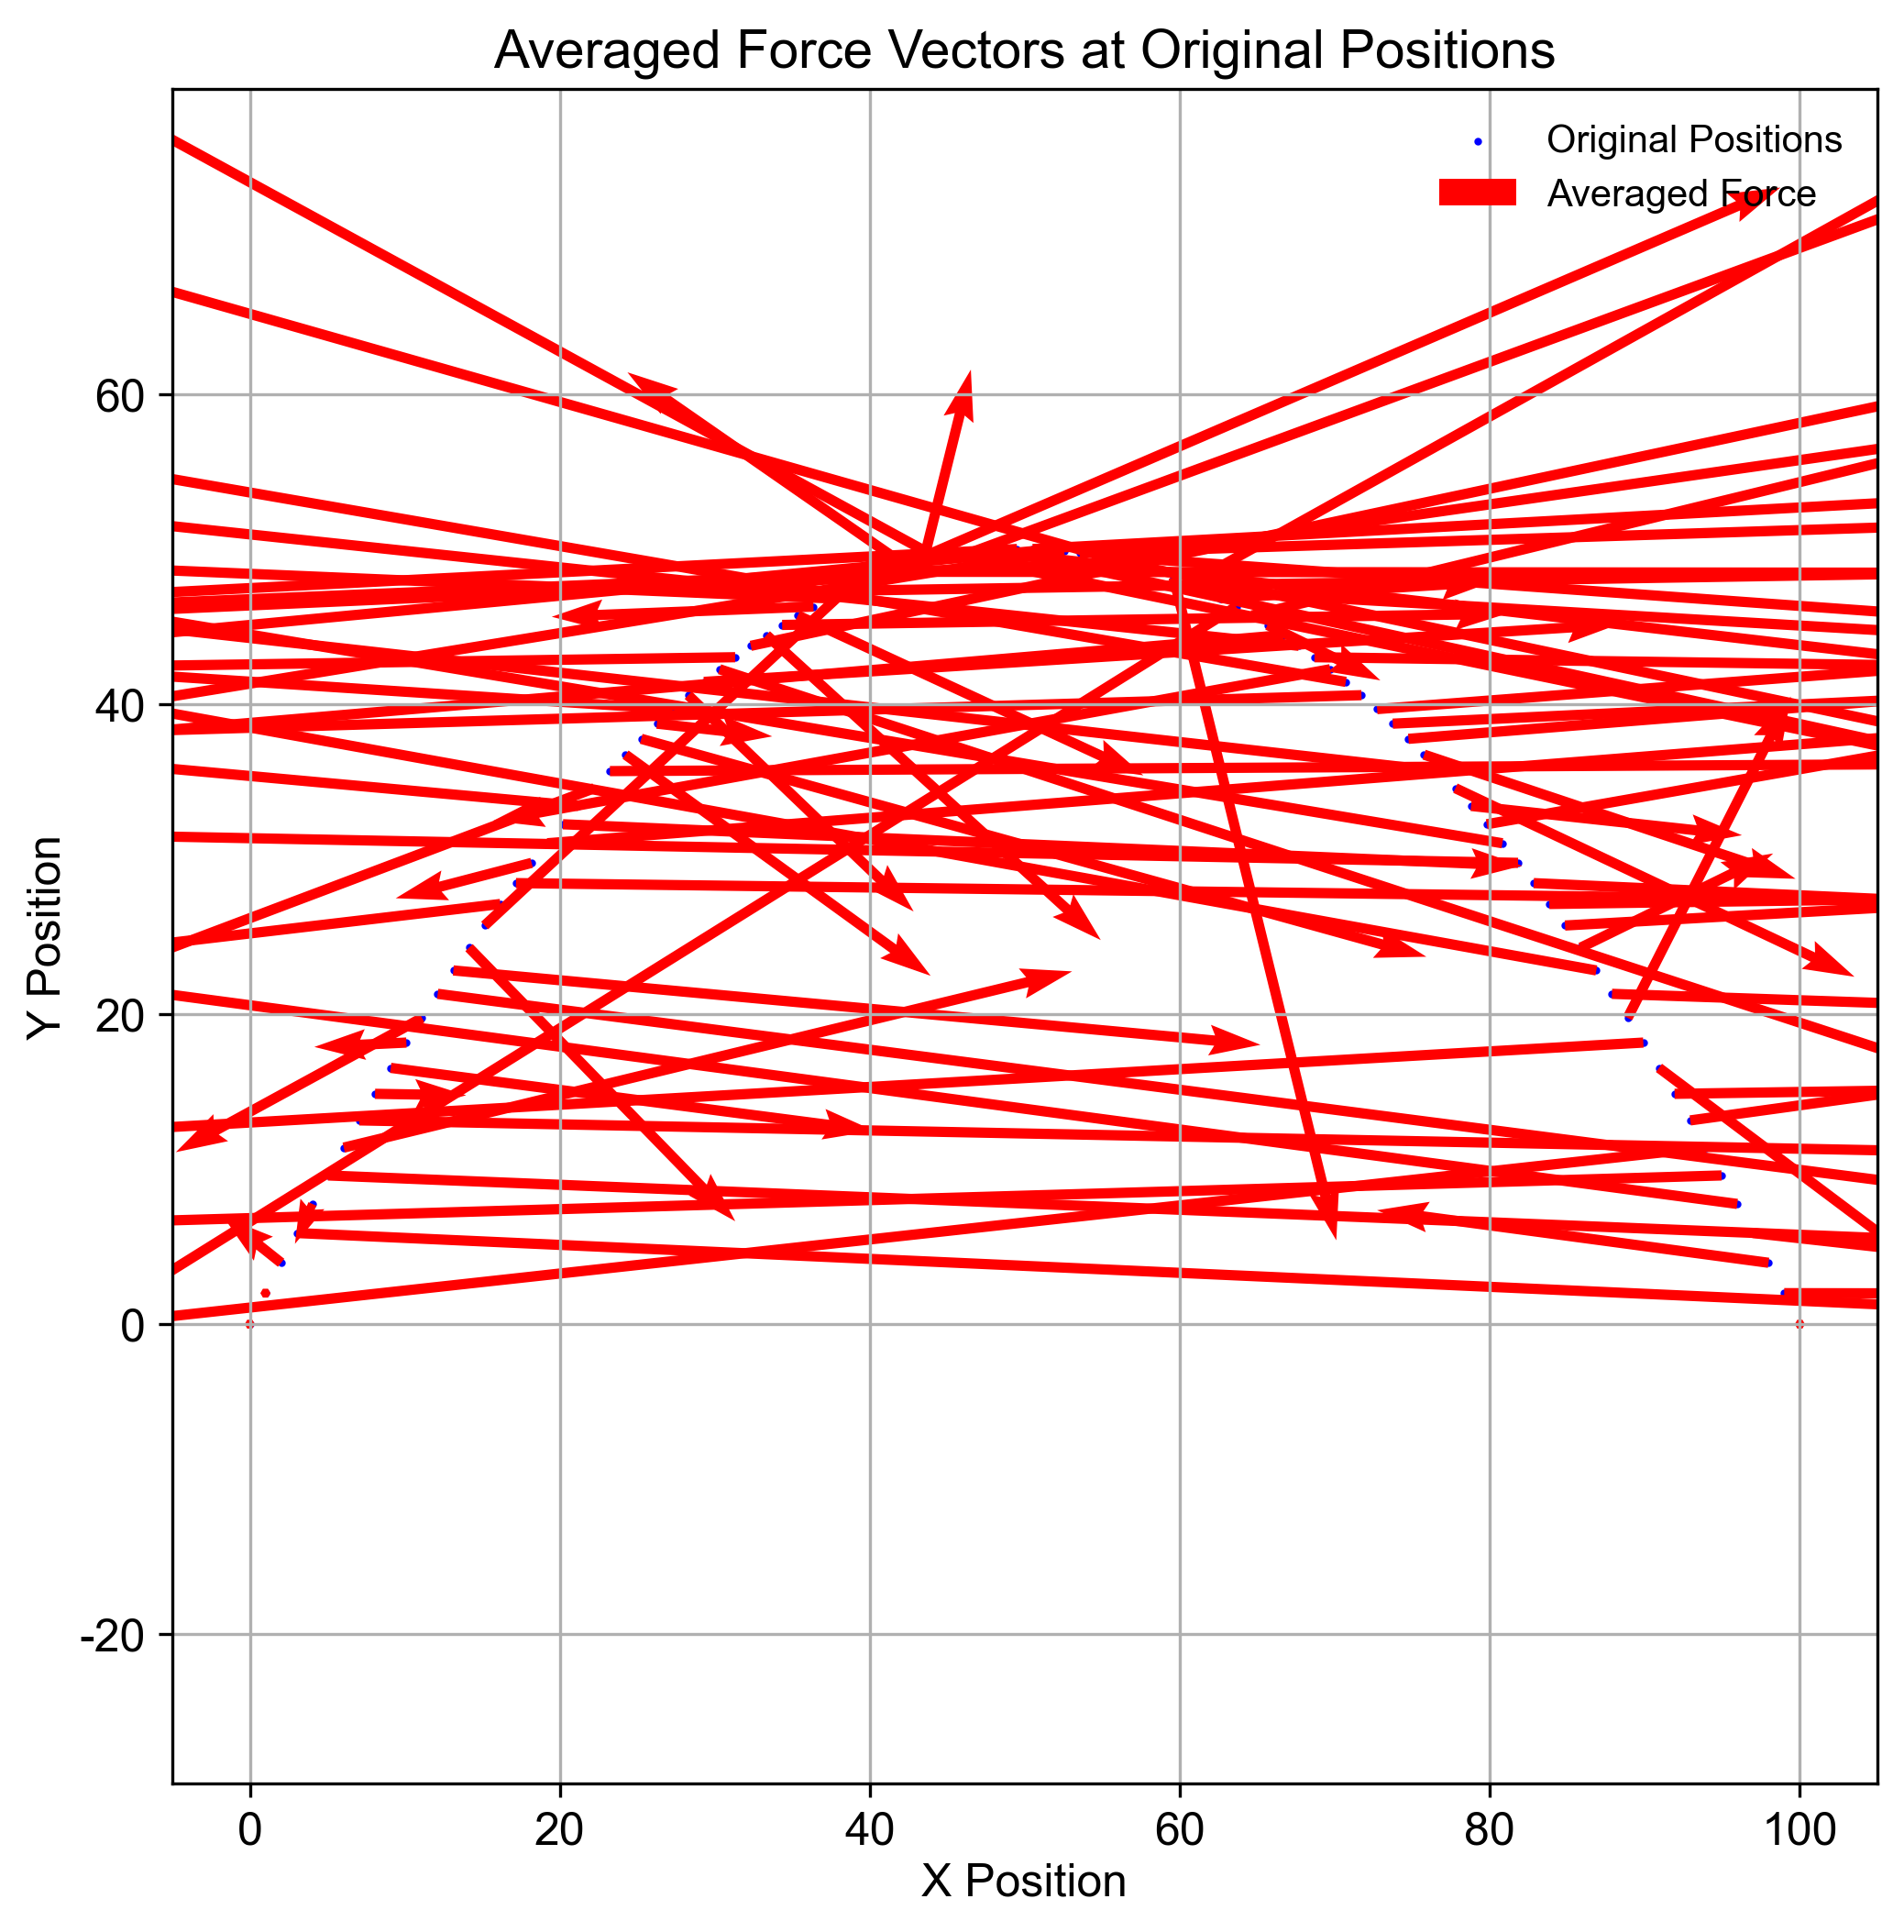

In [1]:
# Parabola with noise

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sample import make_parabola, add_noise, calc_arc
from variation_relax import resample, relax_bending
from variation_run import get_force_density

N_node = 100
L_etoe = 100
height = 50
noise_level = 1
n_iter = range(0, 10)

parameters = {
    "Kb":  100 / 4,  # Bending modulus (pN nm)
    "Ksg": 0.5,      # Global stretching modulus (pN nm)
    "Ksl": 0,
    "boundary": "fixed"
}
ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif")


# Initialize storage
n_bins = N_node  # Number of bins
bin_edges = np.linspace(0, 1, n_bins + 1)  # Divide [0, 1] into n_bins bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
force_sum = np.zeros((n_bins, 2))  # To store sum of forces (x, y) in each bin
force_count = np.zeros(n_bins)  # To count entries in each bin

# Range of iterations to test
n_iters = range(0, 10)  # Example: Test for 1 to 100 iterations

# Accumulate data
# for i in n_iters:
for i in tqdm(n_iters, desc="Processing iterations"):
    coords = add_noise(ori_coords, noise_level, i)
    coords = coords[coords[:, 0].argsort()]  # Sort coordinates by x
    arclen = calc_arc(coords)
    forces = get_force_density(parameters, coords)
    forces = forces[0]
    
    # Bin the data
    bin_indices = np.digitize(arclen, bin_edges) - 1  # Get bin indices for arclen
    for idx, force in zip(bin_indices, forces):
        if 0 <= idx < n_bins:  # Ensure index is valid
            force_sum[idx] += force  # Add the force vector to the bin
            force_count[idx] += 1  # Increment the count for the bin

# Compute statistics
valid_bins = force_count > 0  # Avoid division by zero
avg_forces = np.zeros_like(force_sum)  # Initialize mean force
std_forces = np.zeros_like(force_sum)  # Initialize standard deviation

# Compute means for valid bins
avg_forces[valid_bins] = force_sum[valid_bins] / force_count[valid_bins, None]





# Plot the original positions
plt.figure(figsize=(8, 8))
plt.scatter(ori_coords[:, 0], ori_coords[:, 1], color='blue', label='Original Positions')

# Plot the averaged vectors as arrows
plt.quiver(
    ori_coords[:, 0],  # x-coordinates
    ori_coords[:, 1],  # y-coordinates
    avg_forces[:, 0],  # x-component of force
    avg_forces[:, 1],  # y-component of force
    angles='xy', scale_units='xy', scale=1, color='red', label='Averaged Force'
)

# Add labels and legend
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Averaged Force Vectors at Original Positions')
plt.legend()
plt.grid()
plt.axis('equal')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

N_node = 100
L_etoe = 100
height = 50
noise_level = 1
n_iter = range(0, 10)

parameters = {
    "Kb":  100 / 4,  # Bending modulus (pN nm)
    "Ksg": 0.5,      # Global stretching modulus (pN nm)
    "Ksl": 0,
    "boundary": "fixed"
}
ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif")

# Initialize variables
snapshots = []
snapshot_iters = [1, 10, 100, 1000, 10000]  # Iterations to capture snapshots
f_bend_sum   = np.zeros((n_bins, 2))
f_bend_count = np.zeros(n_bins)  
f_surf_sum   = np.zeros((n_bins, 2))
f_surf_count = np.zeros(n_bins)  

# Loop through iterations
for i in tqdm(range(1, max(snapshot_iters) + 1), desc="Processing iterations"):
    coords = add_noise(ori_coords, noise_level, i)
    coords = coords[coords[:, 0].argsort()]
    arclen = calc_arc(coords)
    forces = get_force_density(parameters, coords)
    f_bend = forces[0]
    f_surf = forces[1]

    # Bin the data
    bin_indices = np.digitize(arclen, bin_edges) - 1
    for idx, fb, fs in zip(bin_indices, f_bend, f_surf):
        if 0 <= idx < n_bins:
            f_bend_sum[idx]   += fb
            f_bend_count[idx] += 1
            f_surf_sum[idx]   += fs
            f_surf_count[idx] += 1
            
    # Store snapshot if this iteration is in snapshot_iters
    if i in snapshot_iters:
        valid_bins = force_count > 0
        avg_f_bend = np.zeros_like(f_bend_sum)
        avg_f_surf = np.zeros_like(f_surf_sum)
        avg_f_bend[valid_bins] = f_bend_sum[valid_bins] / f_bend_count[valid_bins, None]
        avg_f_surf[valid_bins] = f_surf_sum[valid_bins] / f_surf_count[valid_bins, None]

        file_path = os.path.join(f"dat/average_test", f"n{N_node}_{noise_level:.2f}".replace('.', '') + f"_i{i}.npz")
        np.savez(file_path, bend = avg_f_bend, surf = avg_f_surf)



Processing iterations:   0%|                                                  | 0/10000 [00:00<?, ?it/s]/var/folders/cw/x3zk4gnn7gbc8tk9rk99gq7m0000gn/T/ipykernel_99218/3860774771.py:50: RuntimeWarning: invalid value encountered in divide
  avg_f_bend[valid_bins] = f_bend_sum[valid_bins] / f_bend_count[valid_bins, None]
/var/folders/cw/x3zk4gnn7gbc8tk9rk99gq7m0000gn/T/ipykernel_99218/3860774771.py:51: RuntimeWarning: invalid value encountered in divide
  avg_f_surf[valid_bins] = f_surf_sum[valid_bins] / f_surf_count[valid_bins, None]
Processing iterations:  38%|██████████████▉                        | 3835/10000 [13:22<12:53,  7.97it/s]

In [ ]:
# test #
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sample import make_parabola, add_noise, calc_arc
from variation_relax import resample, relax_bending
from variation_run import get_force_density

N_node = 100
L_etoe = 100
height = 50
noise_level = 1

parameters = {
    "Kb":  100 / 4,  # Bending modulus (pN nm)
    "Ksg": 0.5,      # Global stretching modulus (pN nm)
    "Ksl": 0,
    "boundary": "fixed"
}
ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif")

n_bins = N_node  # Number of bins
bin_edges = np.linspace(0, 1, n_bins + 1)  # Divide [0, 1] into n_bins bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
f_bend_sum   = np.zeros((n_bins, 2))
f_bend_count = np.zeros(n_bins)  
f_surf_sum   = np.zeros((n_bins, 2))
f_surf_count = np.zeros(n_bins)  

n_id = 6

# Loop through iterations
for i in tqdm(range(1+n_id*1000, (n_id+1)*1000 + 1), desc="Processing iterations"):
    coords = add_noise(ori_coords, noise_level, i)
    coords = coords[coords[:, 0].argsort()]
    arclen = calc_arc(coords)
    forces = get_force_density(parameters, coords)
    f_bend = forces[0]
    f_surf = forces[1]

    # Bin the data
    bin_indices = np.digitize(arclen, bin_edges) - 1
    for idx, fb, fs in zip(bin_indices, f_bend, f_surf):
        if 0 <= idx < n_bins:
            f_bend_sum[idx]   += fb
            f_bend_count[idx] += 1
            f_surf_sum[idx]   += fs
            f_surf_count[idx] += 1
            
# valid_bins = force_count > 0
# avg_f_bend = np.zeros_like(f_bend_sum)
# avg_f_surf = np.zeros_like(f_surf_sum)
# avg_f_bend[valid_bins] = f_bend_sum[valid_bins] / f_bend_count[valid_bins, None]
# avg_f_surf[valid_bins] = f_surf_sum[valid_bins] / f_surf_count[valid_bins, None]

file_path = os.path.join(f"dat/average_test", f"n{N_node}_{noise_level:.2f}".replace('.', '') + f"_id{n_id}.npz")
np.savez(file_path, f_bend_sum = f_bend_sum, f_surf_sum = f_surf_sum, f_bend_count = f_bend_count, f_surf_count = f_surf_count)

Processing iterations:   9%|███▋                                      | 87/1000 [00:09<01:34,  9.67it/s]

In [8]:
# test #
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sample import make_parabola, add_noise, calc_arc
from variation_relax import resample, relax_bending
from variation_run import get_force_density

N_node = 100
L_etoe = 100
height = 50
noise_level = 1
n_iter = range(0, 10)

n_bins = N_node  # Number of bins
bin_edges = np.linspace(0, 1, n_bins + 1)  # Divide [0, 1] into n_bins bins
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
f_bend_sum   = np.zeros((n_bins, 2))
f_bend_count = np.zeros(n_bins)  
f_surf_sum   = np.zeros((n_bins, 2))
f_surf_count = np.zeros(n_bins) 

for n_id in range(0,6):
    file_path = os.path.join(f"dat/average_test", f"n{N_node}_{noise_level:.2f}".replace('.', '') + f"_id{n_id}.npz")
    data = np.load(file_path)
    f_bend_sum_tmp = data['f_bend_sum']
    f_surf_sum_tmp = data['f_surf_sum']
    f_bend_count_tmp = data['f_bend_count']
    f_surf_count_tmp = data['f_surf_count']

    f_bend_sum += f_bend_sum_tmp
    f_surf_sum += f_surf_sum_tmp
    f_bend_count += f_bend_count_tmp
    f_surf_count += f_surf_count_tmp

valid_bins = f_bend_count > 0
avg_f_bend = np.zeros_like(f_bend_sum)
avg_f_surf = np.zeros_like(f_surf_sum)
avg_f_bend[valid_bins] = f_bend_sum[valid_bins] / f_bend_count[valid_bins, None]
avg_f_surf[valid_bins] = f_surf_sum[valid_bins] / f_surf_count[valid_bins, None]

n_iter = 6000
file_path = os.path.join(f"dat/average_test", f"n{N_node}_{noise_level:.2f}".replace('.', '') + f"_i{n_iter}.npz")
np.savez(file_path, bend = avg_f_bend, surf = avg_f_surf)

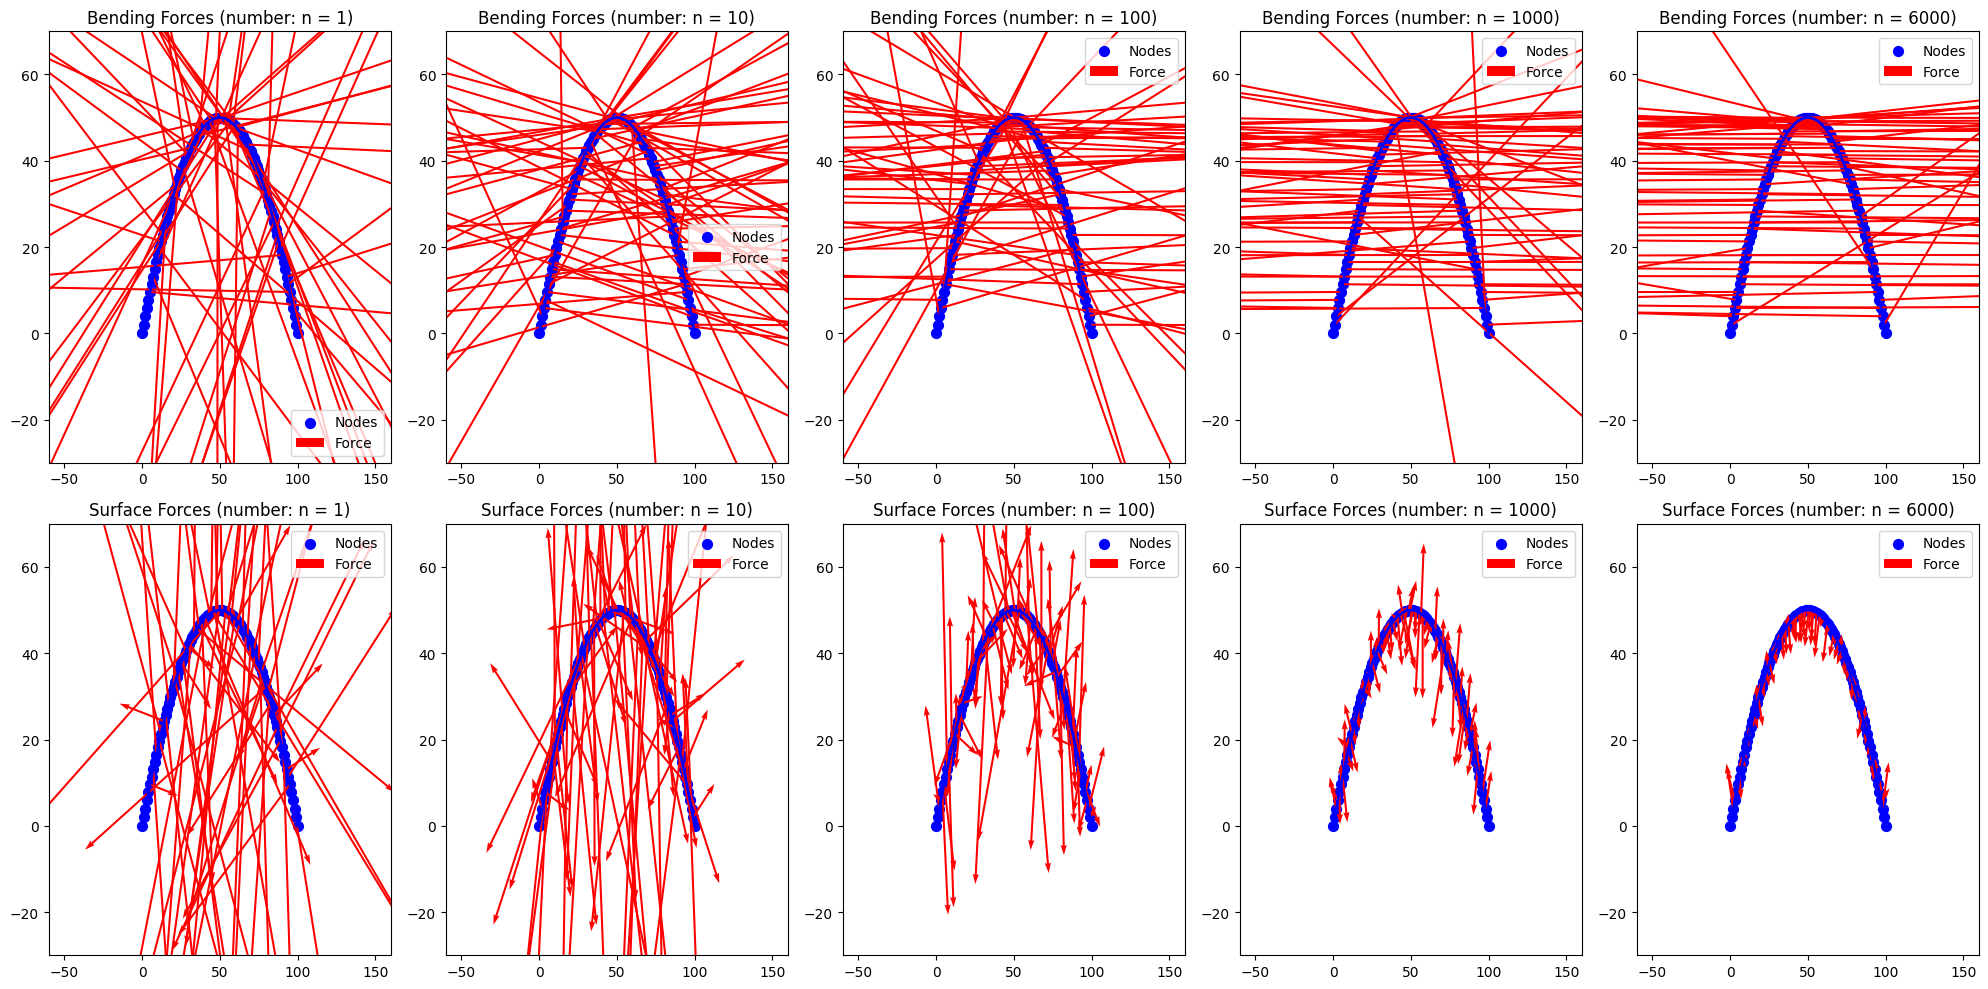

In [4]:
from sample import plot_parabola_ax, make_parabola
import os
import numpy as np
import matplotlib.pyplot as plt

N_node = 100
L_etoe = 100
height = 50
noise_level = 1
n_iter = range(0, 10)
ori_coords = make_parabola(N_node = N_node, L_etoe = L_etoe, height = height, point_dist = "unif")


n_iter_values = [1, 10, 100, 1000, 6000]

fig, axes = plt.subplots(2, len(n_iter_values), figsize=(20, 10))
for idx, n_iter in enumerate(n_iter_values):

    file_path = os.path.join(f"dat/average_test", f"n{N_node}_{noise_level:.2f}".replace('.', '') + f"_i{n_iter}.npz")
    data = np.load(file_path)
    bend = data['bend']
    surf = data['surf']

    # Plot Bending Force (row 0)
    plot_parabola_ax(ori_coords, bend, ax=axes[0, idx], n_iter=n_iter, force_type="Bending Forces", scale=100)
    
    # Plot Surface Force (row 1)
    plot_parabola_ax(ori_coords, surf, ax=axes[1, idx], n_iter=n_iter, force_type="Surface Forces", scale=100)    

fig.tight_layout()
plt.show()
